## 1. Objetivo

In [44]:
import sys
from pathlib import Path

# Raíz del proyecto
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [45]:
import pandas as pd
import seaborn as sns
from pathlib import Path
from src.preprocessing import load_data

## 2. Cargar datos

In [46]:
df_ventas, df_catalogo, df_tiendas, df_inventario = load_data()

## 3. Calidad de datos

In [47]:
df_catalogo.head(2)

,id_producto,nombre,categoria,costo_unitario,precio_venta,costo_almacenamiento_semanal
0,PROD_001,Tinto,Bebidas,800,2500,10
1,PROD_002,Café con Leche,Bebidas,1200,3500,15


In [48]:
df_inventario.head(2)

,id_tienda,id_producto,stock_actual
0,STORE_01,PROD_001,1
1,STORE_01,PROD_002,10


In [49]:
df_tiendas.head(2)

,id_tienda,ciudad,tamaño_m2
0,STORE_01,Bogotá,28
1,STORE_02,Bogotá,43


In [50]:
df_ventas.head(2)

,fecha,id_tienda,id_producto,unidades_vendidas
0,2024-01-01,STORE_01,PROD_001,5
1,2024-01-02,STORE_01,PROD_001,4


In [51]:
df_ventas.info()
df_catalogo.info()
df_inventario.info()
df_tiendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14560 entries, 0 to 14559
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   fecha              14560 non-null  object
 1   id_tienda          14560 non-null  object
 2   id_producto        14560 non-null  object
 3   unidades_vendidas  14560 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 455.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   id_producto                   8 non-null      object
 1   nombre                        8 non-null      object
 2   categoria                     8 non-null      object
 3   costo_unitario                8 non-null      int64 
 4   precio_venta                  8 non-null      int64 
 5   costo_almacenamiento_semanal  8 non-null      i

In [52]:
for name, df in {
    "ventas": df_ventas,
    "catalogo": df_catalogo,
    "inventario": df_inventario,
    "tiendas": df_tiendas
}.items():
    print(name, df.isna().sum().sum())

ventas 0
catalogo 0
inventario 0
tiendas 0


In [53]:
for name, df in {
    "ventas": df_ventas,
    "catalogo": df_catalogo,
    "inventario": df_inventario,
    "tiendas": df_tiendas
}.items():
    print(name, df.duplicated().sum())

ventas 0
catalogo 0
inventario 0
tiendas 0


## 3. Análisis de ventas

In [54]:
print(df_ventas["id_tienda"].nunique())
print(df_ventas["id_producto"].nunique())
print(df_ventas["fecha"].nunique())

20
8
91


In [55]:
df_ventas["fecha"] = pd.to_datetime(df_ventas["fecha"])

In [56]:
print(df_ventas["fecha"].min())
print(df_ventas["fecha"].max())

2024-01-01 00:00:00
2024-03-31 00:00:00


In [57]:
df_ventas["unidades_vendidas"].describe()

count    14560.000000
mean        13.177266
std          7.791471
min          0.000000
25%          7.000000
50%         12.000000
75%         17.000000
max         58.000000
Name: unidades_vendidas, dtype: float64

<Axes: xlabel='unidades_vendidas', ylabel='Count'>

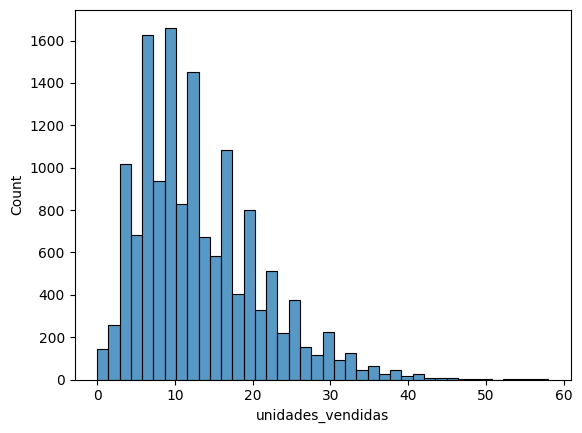

In [58]:
sns.histplot(df_ventas["unidades_vendidas"], bins=40)

<Axes: xlabel='fecha'>

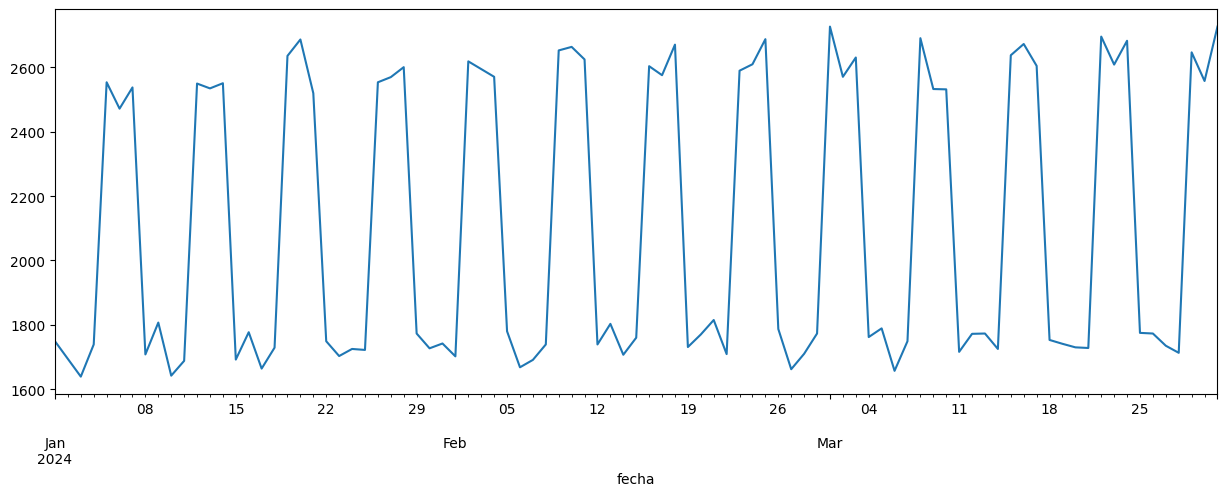

In [59]:
ventas_diarias = (df_ventas .groupby("fecha")["unidades_vendidas"] .sum())
ventas_diarias.plot(figsize=(15,5))

In [60]:
df_ventas .groupby("id_producto")["unidades_vendidas"] .sum() .sort_values(ascending=False) .head(10)

id_producto
PROD_005    32489
PROD_007    31469
PROD_008    29833
PROD_006    28895
PROD_003    21249
PROD_002    20580
PROD_001    14971
PROD_004    12375
Name: unidades_vendidas, dtype: int64

In [61]:
df_ventas .groupby("id_tienda")["unidades_vendidas"].sum().sort_values(ascending=False).head()

id_tienda
STORE_16    14582
STORE_08    14252
STORE_03    11658
STORE_04    11281
STORE_02    10690
Name: unidades_vendidas, dtype: int64

In [62]:
ventas_catalogo = df_ventas.merge(df_catalogo, on="id_producto", how="left")

In [63]:
ventas_catalogo.groupby("categoria")["unidades_vendidas"].sum()

categoria
Alimentos    105228
Bebidas       86633
Name: unidades_vendidas, dtype: int64

In [64]:
ventas_tienda = ventas_catalogo.merge(df_tiendas, on="id_tienda", how="left")

In [65]:
ventas_tienda.groupby('tamaño_m2')['unidades_vendidas'].sum().sort_values(ascending=False).head()

tamaño_m2
34    29709
33    28895
49    28834
42    11658
40    11281
Name: unidades_vendidas, dtype: int64